In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import joblib
from sklearn.metrics import precision_recall_curve, f1_score

In [6]:
# --- CONFIGURATION ---
# Ensure these match your dataset!
NORMAL_LABEL = 1   # Baseline
ANOMALY_LABEL = 2  # Stress

In [7]:
# --- CONFIGURATION ---
# Ensure these match your dataset!
NORMAL_LABEL = 1   # Baseline
ANOMALY_LABEL = 2  # Stress

# --- HELPER 1: SMOOTHING ---
def smooth_errors(loss_array, window_size=5):
    """Applies a simple moving average to the error signal."""
    weights = np.ones(window_size) / window_size
    return np.convolve(loss_array, weights, mode='same')

# --- HELPER 2: F1 OPTIMIZATION ---
def find_optimal_threshold(y_true, loss_values):
    """Finds the threshold that maximizes the F1-Score."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, loss_values)
    
    # Calculate F1 for every threshold (adding epsilon to avoid div by zero)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

def evaluate_anomaly_detector():
    print("1. Loading Pre-Scaled Data & Model...")
    # This data is already scaled per-patient from the preprocessing step
    X = np.load('X_data_ALL.npy')
    y = np.load('y_data_ALL.npy')
    
    print(f"Unique labels in y: {np.unique(y)}")
    if NORMAL_LABEL not in y or ANOMALY_LABEL not in y:
        print(f"WARNING: Your data does not contain Label {NORMAL_LABEL} or {ANOMALY_LABEL}. Check your constants!")

    model = tf.keras.models.load_model('gru_autoencoder.h5')
    
    # --- NOTE: Global Scaling Step Removed! ---
    # We no longer load 'guardian_scaler.pkl' because scaling globally 
    # across all patients destroys the relative HRV baselines.

    # --- 2. Get Reconstructions ---
    print("Reconstructing data...")
    # Feed the pre-scaled X directly into the model
    reconstructions = model.predict(X)
    
    # --- 3. Calculate Error ---
    train_loss = np.mean(np.abs(reconstructions - X), axis=(1,2))
    
    # --- SMOOTHING ---
    print("Applying Temporal Smoothing...")
    train_loss = smooth_errors(train_loss, window_size=10)

    # ============================================================
    # --- STEP 4: DETERMINE OPTIMAL THRESHOLD (F1-Score) ---
    # ============================================================
    print("Optimizing Threshold for F1-Score...")
    
    # Filter data: Keep only Normal and Stress for evaluation
    mask = np.isin(y, [NORMAL_LABEL, ANOMALY_LABEL])
    y_filtered = y[mask]
    loss_filtered = train_loss[mask]
    
    # Convert to Binary (0=Normal, 1=Anomaly)
    y_binary = np.where(y_filtered == ANOMALY_LABEL, 1, 0)
    
    # Find the best threshold automatically
    best_thresh, best_f1 = find_optimal_threshold(y_binary, loss_filtered)
    
    print(f"Optimal Threshold Found: {best_thresh:.4f}")
    print(f"Max F1-Score: {best_f1:.4f}")
    
    threshold = best_thresh
    # ============================================================
    
    # --- 5. Classify ---
    preds = (loss_filtered > threshold).astype(int)
    
    # --- 6. Metrics ---
    print("\n--- RESULTS ---")
    print(f"Accuracy:  {accuracy_score(y_binary, preds):.4f}")
    print(f"Precision: {precision_score(y_binary, preds):.4f}")
    print(f"Recall:    {recall_score(y_binary, preds):.4f}")
    
    cm = confusion_matrix(y_binary, preds)
    print("\nConfusion Matrix:")
    print(cm)
    
    # --- 7. Visualization ---
    normal_loss_plot = train_loss[y == NORMAL_LABEL]
    anomaly_loss_plot = train_loss[y == ANOMALY_LABEL]
    
    plt.figure(figsize=(10, 6))
    sns.histplot(normal_loss_plot, bins=50, alpha=0.6, label='Normal (Baseline)', color='blue', kde=True)
    sns.histplot(anomaly_loss_plot, bins=50, alpha=0.6, label='Anomaly (Stress)', color='red', kde=True)
    plt.axvline(threshold, color='k', linestyle='--', label=f'Threshold ({threshold:.3f})')
    plt.title("Reconstruction Error (F1-Optimized, All Patients)")
    plt.xlabel("Reconstruction Error (MAE)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

1. Loading Pre-Scaled Data & Model...
Unique labels in y: [1 2 3 4]
Reconstructing data...
705/705 [==============================] - 78s 109ms/step
Applying Temporal Smoothing...
Optimizing Threshold for F1-Score...
Optimal Threshold Found: 0.0504
Max F1-Score: 0.7343

--- RESULTS ---
Accuracy:  0.8046
Precision: 0.7603
Recall:    0.7098

Confusion Matrix:
[[7635 1215]
 [1576 3854]]


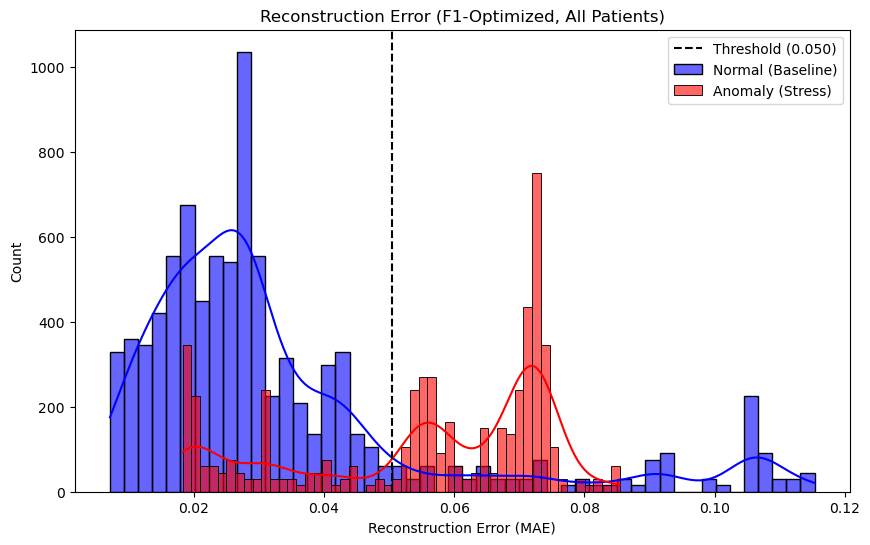

In [8]:
if __name__ == "__main__":
    evaluate_anomaly_detector()